# Rapid proteomic analysis for solid tumors reveals LSD1 as a drug target in an end‐stage cancer patient
#### Doll et al. https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6068348/

### Abstract
Recent advances in mass spectrometry (MS)‐based technologies are now set to transform translational cancer proteomics from an idea to a practice. Here, we present a robust proteomic workflow for the analysis of clinically relevant human cancer tissues that allows quantitation of thousands of tumor proteins in several hours of measuring time and a total turnaround of a few days. We applied it to a chemorefractory metastatic case of the extremely rare urachal carcinoma. Quantitative comparison of lung metastases and surrounding tissue revealed several significantly upregulated proteins, among them lysine‐specific histone demethylase 1 (LSD1/KDM1A). LSD1 is an epigenetic regulator and the target of active development efforts in oncology. Thus, clinical cancer proteomics can rapidly and efficiently identify actionable therapeutic options. While currently described for a single case study, we envision that it can be applied broadly to other patients in a similar condition.

### Workflow

![Figure 2](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6068348/bin/MOL2-12-1296-g002.jpg)

**Figure 2** Proteomics workflow for the case study. (A) Timeline of the project. (B) Experimental design, including source of material, inStageTip sample preparation, and depiction of the analytical workflow


### Results

![Figure 3](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6068348/bin/MOL2-12-1296-g003.jpg)

**Figure 3** Proteins differentially expressed in the urachal carcinoma lung metastases. (A) Volcano plot of the p‐values (y‐axis) vs. the log2 protein abundance differences (x‐axis) between metastases and control, with lines of significance colored in black or gray lines corresponding to a 5% or 1% FDR, respectively. (B) Mechanisms of action of LSD1/KDM1A and inhibitory drug treatment proposed: **JATROSOME. TRANYLCYPROMIN**


### Workflow with the Clinical Knowledge Graph

1. Generate Analysis Report: Proteomics data
2. Identify Candidate Drug Treatments
3. Rank Candidates According to Toxicity

![Clinical_Knowledge_Graph](banner.jpg)

## Generate Analysis Report: Proteomics Data

### Report Manager

In [206]:
from ckg.report_manager import project

from plotly.offline import init_notebook_mode, iplot
%matplotlib inline
init_notebook_mode(connected=True)

##### We load specific configuration for this project.

In [207]:
configuration_files = {"proteomics":"../assets/proteomics_CS.yml"}

##### We create a new project object that we can use to run the analyses

In [208]:
study_case_project = project.Project(identifier="P0000002", configuration_files=configuration_files, datasets={}, knowledge=None, report={})

##### We need to first build the project. This step will collect the project datasets from CKG and process them

In [209]:
study_case_project.build_project(force=False)

##### We can now generate the report following the specified configuration

In [210]:
study_case_project.generate_report()

##### We can access the project report

In [211]:
study_case_project.show_report(environment='notebook')

defaultdict(list,
            {'PROJECT INFORMATION': [],
             'PROTEOMICS': [],
             'MULTIOMICS': [],
             'KNOWLEDGE GRAPH': []})

##### Ready! All the analyses are done and we can now access to all the results for each data type

In [212]:
study_case_project.list_datasets()

dict_keys(['multiomics', 'proteomics'])

##### We will use the results from the proteomics analyses. We access the dataset 'proteomics' for further analysis.

In [213]:
proteomics_dataset = study_case_project.get_dataset(dataset='proteomics')

##### The available analysis for this dataset are:

In [214]:
proteomics_dataset.list_dataframes()

['go annotation',
 'number of modified proteins',
 'number of peptides',
 'number of proteins',
 'original',
 'pathway annotation',
 'processed',
 'protein biomarkers',
 'regulated',
 'regulation table',
 'tissue qcmarkers']

###### In this case, we use the regulation table to extract proteins upregulated in the metastatic tissue compare to non-cancerous tissue.

In [215]:
regulation_table = proteomics_dataset.get_dataframe(dataset_name='regulation table')

In [216]:
regulation_table.head()

,-log10 pvalue,FC,Method,T-statistics,correction,dfk,dfn,effsize,efftype,group1,...,identifier,log2FC,mean(group1),mean(group2),padj,pvalue,rejected,s0,std(group1),std(group2)
0,0.487413,-1.277214,SAMR Two class paired,0.153337,permutation FDR (4.0 perm),1,2,-0.738,hedges,CANCER,...,A1BG~P04217,-0.353,31.710,32.063,0.714951,0.325527,False,2,0.047,0.384
1,1.438878,3.610003,SAMR Two class paired,-0.924233,permutation FDR (4.0 perm),1,2,2.913,hedges,CANCER,...,A1CF~Q9NQ94,1.852,26.563,24.711,0.052925,0.036402,False,2,0.360,0.366
2,3.001177,-1.926524,SAMR Two class paired,0.463202,permutation FDR (4.0 perm),1,2,-18.081,hedges,CANCER,...,A2M~P01023,-0.946,34.287,35.233,0.271411,0.000997,False,2,0.033,0.026
3,1.192262,2.801113,SAMR Two class paired,-0.594485,permutation FDR (4.0 perm),1,2,2.145,hedges,CANCER,...,AAAS~Q9NRG9,1.486,26.317,24.831,0.149537,0.064230,False,2,0.173,0.532
4,0.321607,-1.786332,SAMR Two class paired,0.346611,permutation FDR (4.0 perm),1,2,-0.496,hedges,CANCER,...,AACS~Q86V21,-0.837,26.350,27.187,0.423692,0.476862,False,2,0.625,1.211


In [217]:
regulation_table[regulation_table['identifier']=='HDAC1~Q13547']

,-log10 pvalue,FC,Method,T-statistics,correction,dfk,dfn,effsize,efftype,group1,...,identifier,log2FC,mean(group1),mean(group2),padj,pvalue,rejected,s0,std(group1),std(group2)
1885,0.782856,10.367528,SAMR Two class paired,-1.008813,permutation FDR (4.0 perm),1,2,1.227,hedges,CANCER,...,HDAC1~Q13547,3.374,30.666,27.292,0.036735,0.164871,True,2,0.301,2.201


##### As in the article, we use significantly regulated proteins with a fold change higher than two.

In [218]:
up_regulated_proteins = regulation_table.loc[(regulation_table.rejected) & (regulation_table.FC > 2), ['identifier']]

In [219]:
up_regulated_proteins.shape

(199, 1)

In [220]:
'HDAC1~Q13547' in up_regulated_proteins['identifier'].tolist()

True

### Graph Database Connector

In [221]:
from ckg.graphdb_connector import query_utils, connector

##### We connect to CKG database using the default configuration

In [222]:
driver = connector.getGraphDatabaseConnectionConfiguration()

##### We load the existing database queries that we can use to extract knowledge from CKG

In [223]:
queries = query_utils.read_knowledge_queries()

### 1) Filter for Regulated Proteins Associated to Lung Cancer:

##### We want to check whether we can identify known connection between the upregulated proteins in metastases and the disease
##### We check if there are queries for these node types: Protein, Disease

In [224]:
selected_queries = query_utils.find_queries_involving_nodes(queries=queries, nodes=["Protein", "Disease"], print_pretty=True)

In [225]:
selected_queries.head()

,Name,Description,involved_nodes,involved_rels,query,example
id,,,,,,
Disease,associated diseases in at least two of the pro...,get relationships to diseases from a list of p...,"Protein,Disease",ASSOCIATED_WITH,MATCH (project:Project)-[:STUDIES_DISEASE]-(d:...,
association_disease_score,specific disease,Return the list of proteins associated to a sp...,"Protein,Disease",ASSOCIATED_WITH,MATCH (protein:Protein)-[r]-(disease:Disease) ...,"proteins = ['A1BG~P04217','A2M~P01023','ACACB~..."


##### The query named 'specific disease' can help us in this case

In [226]:
disease_query = selected_queries.loc["association_disease_score", "query"]
proteins = ['"{}"'.format(p) for p in up_regulated_proteins["identifier"].tolist()]
diseases = ['DOID:1324']
diseases = ['"{}"'.format(d) for d in diseases]
disease_query = disease_query.format(",".join(proteins),",".join(diseases), 1)

In [227]:
proteins_associated_lung_cancer = connector.getCursorData(driver=driver, query=disease_query, parameters={})

In [228]:
proteins_associated_lung_cancer.head()

,node1,node2,source,type,weight
0,SLC44A1~Q8WWI5,lung cancer,DISEASES,ASSOCIATED_WITH,1.026
1,IRF6~O14896,lung cancer,DISEASES,ASSOCIATED_WITH,1.192
2,SPINT2~O43291,lung cancer,DISEASES,ASSOCIATED_WITH,1.216
3,KDM1A~O60341,lung cancer,DISEASES,ASSOCIATED_WITH,2.405
4,CEACAM5~P06731,lung cancer,DISEASES,ASSOCIATED_WITH,3.122


In [229]:
proteins_associated_lung_cancer.shape

(69, 5)

### 2) Identify Inhibitory Drugs for those Proteins

##### We use again the functionality 'find_queries_involving_nodes' to find queries involving nodes: Protein, Drug

In [230]:
selected_queries = query_utils.find_queries_involving_nodes(queries=queries, nodes=["Protein", "Drug"], print_pretty=True)

In [231]:
selected_queries.head()

,Name,Description,involved_nodes,involved_rels,query,example
id,,,,,,
Drug,associated drugs in at least two of the protei...,get relationships to drugs. Limit the result t...,"Protein,Drug",ACTS_ON,MATCH (protein:Protein)-[r:ACTS_ON]-(drug:Drug...,
association_drug_intervention_proteins,drug intervention- protein association,Return associations between a list of proteins...,"Project,Protein,Clinical_variable,Drug","HAD_INTERVENTION,ACTS_ON",MATCH (project:Project)-[]-()-[:HAD_INTERVENTI...,project_id = 'P0000002'\nproteins = ['A1BG~P04...
association_drug_interaction_score,drug interaction association,Return the list of drugs associated to the lis...,"Protein,Drug",ACTS_ON,MATCH (protein:Protein)-[r]-(drug:Drug) WHERE ...,"proteins = ['A1BG~P04217','A2M~P01023','ACACB~..."


In [232]:
proteins = ['"{}"'.format(p) for p in proteins_associated_lung_cancer['node1'].tolist()]
drug_query = selected_queries.loc["association_drug_interaction_score", "query"].format(",".join(proteins), 'inhibition', 0.8)

##### We search in CKG database for known inhibitory drugs for these proteins

In [233]:
drugs_proposed = connector.getCursorData(driver=driver, query=drug_query, parameters={})

In [234]:
drugs_proposed.head()

,Drug_desc,action,drug_id,node1,node2,source,type,weight
0,None,inhibition,DB04808,ANG~P03950,Neamine,STITCH,ACTS_ON,0.800
1,None,inhibition,DB02198,ANG~P03950,2-Bromoacetyl Group,STITCH,ACTS_ON,0.800
2,Losartan is an angiotensin II receptor blocker...,inhibition,DB00678,ANG~P03950,Losartan,STITCH,ACTS_ON,0.957
3,Tamoxifen is a non-steroidal antiestrogen used...,inhibition,DB00675,ANG~P03950,Tamoxifen,STITCH,ACTS_ON,0.990
4,A macrolide compound obtained from Streptomyce...,inhibition,DB00877,ANG~P03950,Sirolimus,STITCH,ACTS_ON,0.800


In [235]:
drugs_proposed.shape

(67, 8)

##### These list of inhibitory drugs could in principle be used to identify alternative treatments
#### We can already see that CKG found the same inhibitory drug that was identified in the study case published. However, many other options are proposed and could be further ranked using other criteria.

In [236]:
from ckg.analytics_core import utils
from ckg.analytics_core.viz import viz

In [237]:
net = viz.get_network(data=drugs_proposed, identifier="inhibition_drugs", args={"source":"node1", "target":"node2", "values":"weight", "node_size":"degree","title":"Proposed drugs", "color_weight":False})

In [238]:
viz.visualize_notebook_network(net["notebook"], notebook_type='jupyter', layout={'width':'100%', 'height':'700px'})

Cytoscape(data={'elements': [{'data': {'degree': 7, 'betweenness': 0.006024096385542168, 'eigenvector': '-0.00…

In [239]:
utils.json_network_to_gml(net['net_json'], path='drug_network.gml')

##### One possible step to reduce the list would be to use a more stringent cutoff when choosing inhibitory drugs. For instance, a cutoff of 0.9 would provide a candidate list with higher confidence.

In [240]:
proteins = ['"{}"'.format(p) for p in proteins_associated_lung_cancer['node1'].tolist()]
drug_query = queries["association_drug_interaction_score"]["query"].format(",".join(proteins), 'inhibition', 0.9)

##### We search again in CKG database for known inhibitory drugs for these proteins

In [241]:
drugs_proposed = connector.getCursorData(driver=driver, query=drug_query, parameters={})

In [242]:
drugs_proposed.head()

,Drug_desc,action,drug_id,node1,node2,source,type,weight
0,Losartan is an angiotensin II receptor blocker...,inhibition,DB00678,ANG~P03950,Losartan,STITCH,ACTS_ON,0.957
1,Tamoxifen is a non-steroidal antiestrogen used...,inhibition,DB00675,ANG~P03950,Tamoxifen,STITCH,ACTS_ON,0.990
2,Paclitaxel is a chemotherapeutic agent markete...,inhibition,DB01229,CDH1~P12830,Paclitaxel,STITCH,ACTS_ON,0.957
3,A major primary bile acid produced in the live...,inhibition,DB02659,CDH1~P12830,Cholic Acid,STITCH,ACTS_ON,0.957
4,Calcitriol is an active metabolite of vitamin ...,inhibition,DB00136,CDH17~Q12864,Calcitriol,STITCH,ACTS_ON,0.957


In [243]:
drugs_proposed.shape

(15, 8)

##### The list is now shorter but contain only high confidence results

In [244]:
net = viz.get_network(data=drugs_proposed, identifier="inhibition_drugs", args={"source":"node1", "target":"node2", "values":"weight", "node_size":"degree","title":"Proposed drugs", "color_weight":False})

In [245]:
viz.visualize_notebook_network(net["notebook"], notebook_type='jupyter', layout={'width':'100%', 'height':'700px'})

Cytoscape(data={'elements': [{'data': {'degree': 2, 'betweenness': 0.0036231884057971015, 'eigenvector': '-0.0…

In [246]:
utils.json_network_to_gml(net['net_json'], path='drug_network_reduced.gml')

### 3) Identify Proposed Drug's Known Side Effects

##### In the case study, toxicity was in part the reason why the treatment regimens did not work. We could use the list of side effects to prioritize these drugs.

##### Let's find database queries to obtain these associations: Phenotype (side effect), Drug.

In [247]:
selected_queries = query_utils.find_queries_involving_nodes(queries=queries, nodes=["Phenotype", "Drug"], print_pretty=True)

In [248]:
selected_queries.head()

,Name,Description,involved_nodes,involved_rels,query,example
id,,,,,,
association_drug_sideeffects,drug side effect association,Return the list of side effects linked to drugs,"Phenotype,Drug",ASSOCIATED_WITH,MATCH (sideeffect:Phenotype)-[r]-(drug:Drug) W...,"drugs = ['DB00439', 'DB06196']\ndrug_side_effe..."


In [249]:
drugs = drugs_proposed["drug_id"].unique()
drugs = ['"{}"'.format(d) for d in drugs]
sideeffects_query = selected_queries.loc["association_drug_sideeffects", "query"].format(",".join(drugs))

In [250]:
side_effects = connector.getCursorData(driver=driver, query=sideeffects_query, parameters={})

In [251]:
side_effects.head()

,node1,node2,source,type
0,Losartan,Abnormality of fluid regulation,SIDER,HAS_SIDE_EFFECT
1,Losartan,Thrombocytopenia,SIDER,HAS_SIDE_EFFECT
2,Losartan,Nausea,SIDER,HAS_SIDE_EFFECT
3,Losartan,Palpitations,SIDER,HAS_SIDE_EFFECT
4,Losartan,Arthritis,SIDER,HAS_SIDE_EFFECT


In [252]:
side_effects.groupby('node1')['node2'].count()

node1
Atorvastatin    152
Bleomycin        51
Calcitriol       59
Cholic Acid       7
Gemcitabine      94
Glyburide        63
Losartan        120
Paclitaxel      218
Tamoxifen       106
Tolbutamide      18
Vildagliptin     22
Vorinostat       42
Name: node2, dtype: int64

In [253]:
net = viz.get_network(data=side_effects, identifier="side_effects", args={"source":"node1", "target":"node2", "node_size":"degree","title":"Proposed drugs", "color_weight":False})

In [254]:
side_effects.head()

,node1,node2,source,type,width
0,Losartan,Abnormality of fluid regulation,SIDER,HAS_SIDE_EFFECT,1
1,Losartan,Thrombocytopenia,SIDER,HAS_SIDE_EFFECT,1
2,Losartan,Nausea,SIDER,HAS_SIDE_EFFECT,1
3,Losartan,Palpitations,SIDER,HAS_SIDE_EFFECT,1
4,Losartan,Arthritis,SIDER,HAS_SIDE_EFFECT,1


In [255]:
utils.json_network_to_gml(net['net_json'], path='side_effects.gml')

In [256]:
no_registerd_side_effects = list(set(drugs_proposed['node2'].tolist()).difference(side_effects['node1'].tolist()))

In [257]:
no_registerd_side_effects

['Trichostatin A', 'Resveratrol', 'dATP']

### 4) Reduce Adverse Response

##### The treatment regimens are also available in CKG and their side effects can be used to rank the proposed drugs. We can prioritize drugs with side effects dissimilar to the ones that caused an adverse reaction in the patient.

In [258]:
treatment_regimens = pd.DataFrame(['Oxaliplatin',
                     'Capecitabine',
                     'Folinic acid',
                     'Fluorouracil'], columns=['treatment'])

##### We have defined a default query that can be used to calculate Jaccard similarity between two lists of drug treatments. In this case, we can use this query to obtain similarities between side effects from the treatment regimen and the proposed alternative drugs.

In [259]:
selected_queries = query_utils.find_queries_involving_nodes(queries=queries, nodes=["Clinical_variable", "Drug"], print_pretty=True)

In [260]:
selected_queries.head()

,Name,Description,involved_nodes,involved_rels,query,example
id,,,,,,
association_drug_intervention_proteins,drug intervention- protein association,Return associations between a list of proteins...,"Project,Protein,Clinical_variable,Drug","HAD_INTERVENTION,ACTS_ON",MATCH (project:Project)-[]-()-[:HAD_INTERVENTI...,project_id = 'P0000002'\nproteins = ['A1BG~P04...
side_effects_jaccard_similarity_intervention_proposed_drugs,similarity between side effects,Return the jaccard similarity between drugs us...,"Drug,Clinical_variable",HAS_SIDE_EFFECT,MATCH (d1:Drug)-[:HAS_SIDE_EFFECT]->(phenotype...,"intervention = ['Capecitabine', 'Fluorouracil'..."


In [261]:
drugs_proposed

,Drug_desc,action,drug_id,node1,node2,source,type,weight
0,Losartan is an angiotensin II receptor blocker...,inhibition,DB00678,ANG~P03950,Losartan,STITCH,ACTS_ON,0.957
1,Tamoxifen is a non-steroidal antiestrogen used...,inhibition,DB00675,ANG~P03950,Tamoxifen,STITCH,ACTS_ON,0.990
2,Paclitaxel is a chemotherapeutic agent markete...,inhibition,DB01229,CDH1~P12830,Paclitaxel,STITCH,ACTS_ON,0.957
3,A major primary bile acid produced in the live...,inhibition,DB02659,CDH1~P12830,Cholic Acid,STITCH,ACTS_ON,0.957
4,Calcitriol is an active metabolite of vitamin ...,inhibition,DB00136,CDH17~Q12864,Calcitriol,STITCH,ACTS_ON,0.957
5,A complex of related glycopeptide antibiotics ...,inhibition,DB00290,LIG3~P49916,Bleomycin,STITCH,ACTS_ON,0.958
6,Tolbutamide is an oral antihyperglycemic agent...,inhibition,DB01124,GCG~P01275,Tolbutamide,STITCH,ACTS_ON,0.957
7,"Vildagliptin, previously identified as LAF237,...",inhibition,DB04876,GCG~P01275,Vildagliptin,STITCH,ACTS_ON,0.957
8,Glyburide is a second generation sulfonylurea ...,inhibition,DB01016,GCG~P01275,Glyburide,STITCH,ACTS_ON,0.957
9,None,inhibition,DB04297,HDAC1~Q13547,Trichostatin A,STITCH,ACTS_ON,0.938


In [262]:
treatment_list = ['"{}"'.format(t) for t in treatment_regimens['treatment'].tolist()]
proposed_list = ['"{}"'.format(t) for t in drugs_proposed["drug_id"].unique()]
q = selected_queries.loc['side_effects_jaccard_similarity_intervention_proposed_drugs', 'query'].replace("INTERVENTION",",".join(treatment_list)).replace("DRUG",",".join(proposed_list))
similarity = connector.getCursorData(driver=driver, query=q, parameters={})

In [263]:
q

'MATCH (d1:Drug)-[:HAS_SIDE_EFFECT]->(phenotype1) WHERE d1.name in ["Oxaliplatin","Capecitabine","Folinic acid","Fluorouracil"] WITH d1, collect(id(phenotype1)) as treatmentData MATCH (d2:Drug)-[:HAS_SIDE_EFFECT]->(phenotype2) WHERE d2.id IN ["DB00678","DB00675","DB01229","DB02659","DB00136","DB00290","DB01124","DB04876","DB01016","DB04297","DB02546","DB00441","DB02709","DB03222","DB01076"] AND d1 <> d2 WITH d1, treatmentData, d2, collect(id(phenotype2)) as proposedData, size(apoc.coll.intersection(treatmentData, collect(DISTINCT id(phenotype2)))) AS intersection RETURN d1.name AS from, d2.name AS to, intersection, gds.alpha.similarity.jaccard(proposedData, treatmentData) AS similarity ORDER BY similarity DESC\n'

In [264]:
similarity = similarity[(similarity['from'].isin(treatment_regimens['treatment'].tolist())) & (similarity['to'].isin(side_effects['node1'].unique().tolist()))]
similarity = similarity.groupby('to').mean().sort_values(by='similarity')

In [265]:
similarity

,intersection,similarity
to,,
Cholic Acid,5.666667,0.041012
Tolbutamide,11.000000,0.083821
Vildagliptin,15.000000,0.098243
Calcitriol,25.333333,0.156174
Vorinostat,26.000000,0.162747
Bleomycin,28.666667,0.192705
Glyburide,36.000000,0.219190
Tamoxifen,44.000000,0.223948
Gemcitabine,47.000000,0.256839


##### We could initially set a cutoff and further prioritize the reduced list

In [266]:
similarity = similarity[similarity['similarity']<0.2]

In [267]:
similarity

,intersection,similarity
to,,
Cholic Acid,5.666667,0.041012
Tolbutamide,11.000000,0.083821
Vildagliptin,15.000000,0.098243
Calcitriol,25.333333,0.156174
Vorinostat,26.000000,0.162747
Bleomycin,28.666667,0.192705


### 5) Check in Literature Known Links Between Disease and Drugs

##### Drugs that are already known to be have enhancing antitumor effects in primary or metastatic lung cancer could be used as well to prioritize the candidate drugs.

In [268]:
selected_queries = query_utils.find_queries_involving_nodes(queries=queries, nodes=["Disease", "Drug"], print_pretty=True)

In [269]:
selected_queries.head()

,Name,Description,involved_nodes,involved_rels,query,example
id,,,,,,
association_drug_disease_publication,drug co-mentioned with disease in publication,Return the list of publications co-mentioning ...,"Drug,Disease,Publication",MENTIONED_IN_PUBLICATION,MATCH (drug:Drug)-[r:MENTIONED_IN_PUBLICATION]...,"drugs = ['DB00439', 'DB06196']\ndisease = ['D..."
association_combination_drug_disease_publication,combinations of drugs co-mentioned with disease,Return the list of publications co-mentioning ...,"Drug,Disease,Publication",MENTIONED_IN_PUBLICATION,MATCH (drug:Drug)-[r:MENTIONED_IN_PUBLICATION]...,"drugs = ['DB00439', 'DB06196']\ndisease = ['D..."


In [270]:
reduced_drug_list = drugs_proposed.loc[drugs_proposed["node2"].isin(similarity.index.tolist() + no_registerd_side_effects), "drug_id"]
reduced_drug_list = ['"{}"'.format(d) for d in reduced_drug_list]
drug_disease_query = selected_queries.loc['association_drug_disease_publication', 'query'].format(",".join(reduced_drug_list),",".join(diseases))

In [271]:
drugs_publications = connector.getCursorData(driver=driver, query=drug_disease_query, parameters={})

In [272]:
drugs_publications.head()

,Year,linkout,node1,node2,type
0,1988,https://www.ncbi.nlm.nih.gov/pubmed/2454581,dATP,PMID:2454581,MENTIONED_IN_PUBLICATION
1,1992,https://www.ncbi.nlm.nih.gov/pubmed/1562461,Calcitriol,PMID:1562461,MENTIONED_IN_PUBLICATION
2,1981,https://www.ncbi.nlm.nih.gov/pubmed/7236488,Bleomycin,PMID:7236488,MENTIONED_IN_PUBLICATION
3,2007,https://www.ncbi.nlm.nih.gov/pubmed/17583686,Resveratrol,PMID:17583686,MENTIONED_IN_PUBLICATION
4,2009,https://www.ncbi.nlm.nih.gov/pubmed/19760127,Trichostatin A,PMID:19760127,MENTIONED_IN_PUBLICATION


In [273]:
net = viz.get_network(data=drugs_publications, identifier="drugs_publications", args={"source":"node1", "target":"node2", "node_size":"degree","title":"Proposed drugs", "color_weight":False})

In [274]:
utils.json_network_to_gml(net['net_json'], path='drugs_publications.gml')

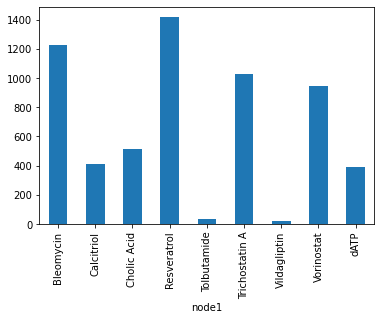

In [275]:
drugs_publications.groupby('node1')["node2"].count().plot.bar();

##### We could also check whether combinations of drugs among the shorted list have been previouly used (co-mentioned in the literature)

In [276]:
drug_combinations_query = selected_queries.loc['association_combination_drug_disease_publication', 'query'].format(",".join(reduced_drug_list),",".join(reduced_drug_list),",".join(reduced_drug_list))


In [277]:
selected_queries.loc['association_combination_drug_disease_publication', 'query']

'MATCH (drug:Drug)-[r:MENTIONED_IN_PUBLICATION]-(publication:Publication) WHERE (drug.id IN [{}]) WITH publication, count(r) AS r_count WHERE r_count>1 MATCH (drug:Drug)-[r:MENTIONED_IN_PUBLICATION]-(publication)-[:MENTIONED_IN_PUBLICATION]-(drug2:Drug) WHERE (drug.id IN [{}]) AND drug2.id IN [{}] AND drug.id<>drug2.id RETURN (drug.name +", "+drug2.name) AS node1, publication.id AS node2, publication.linkout AS linkout, publication.year as Year, type(r) AS type\n'

In [278]:
drugs_combinations = connector.getCursorData(driver=driver, query=drug_combinations_query, parameters={})

In [279]:
drugs_combinations.head()

,Year,linkout,node1,node2,type
0,2010,https://www.ncbi.nlm.nih.gov/pubmed/20371703,"Cholic Acid, Calcitriol",20371703,MENTIONED_IN_PUBLICATION
1,2010,https://www.ncbi.nlm.nih.gov/pubmed/20371703,"Calcitriol, Cholic Acid",20371703,MENTIONED_IN_PUBLICATION
2,2019,https://www.ncbi.nlm.nih.gov/pubmed/31661763,"Cholic Acid, Resveratrol",31661763,MENTIONED_IN_PUBLICATION
3,2019,https://www.ncbi.nlm.nih.gov/pubmed/31661763,"Resveratrol, Cholic Acid",31661763,MENTIONED_IN_PUBLICATION
4,2016,https://www.ncbi.nlm.nih.gov/pubmed/26903812,"Cholic Acid, Calcitriol",26903812,MENTIONED_IN_PUBLICATION


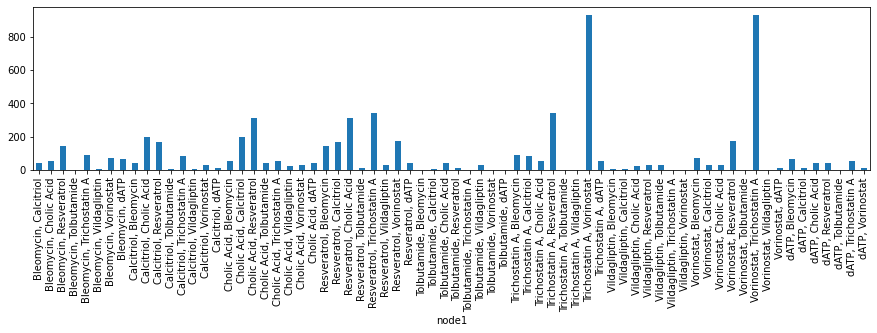

In [280]:
drugs_combinations.groupby('node1')["node2"].count().plot.bar(figsize=(15,3));

##### Some of these combination therapies could be considered.

### 6) Proposed Drug Candidates: 

#### - Vorinostat (https://www.drugbank.ca/drugs/DB02546) 
![Vorinostat](https://www.drugbank.ca/structures/DB02546/image.svg)

####  Trichostatin A (https://www.drugbank.ca/drugs/DB04297)
![7-[4-(Dimethylamino)Phenyl]-N-Hydroxy-4,6-Dimethyl-7-Oxo-2,4-Heptadienamide"](https://www.drugbank.ca/structures/DB04297/image.svg)

In [281]:
import pandas as pd
drug_result = drugs_proposed[drugs_proposed['node2'].isin(['Trichostatin A','Vorinostat'])]
drug_result.columns = ["Drug_desc","Action","Drug_id","Protein","Drug_name","Drug_protein_source","Drug_interaction_type","Inhibition_score"]
drug_result['Side_effects'] = ";".join(side_effects[side_effects['node1']==drug_result["Drug_name"].tolist().pop()]['node2'].tolist())
drug_result['Publications'] = ";".join(drugs_publications[drugs_publications['node1']==drug_result['Drug_name'].tolist().pop()]['node2'].tolist())
protein_result = proteins_associated_lung_cancer[proteins_associated_lung_cancer['node1']==drug_result["Protein"].tolist().pop()]
protein_result.columns = ["Protein", "Disease", "Protein_disease_source", "Protein_disease_association_type", "Disease_score"]
result = pd.merge(drug_result, protein_result, on='Protein')
result = result[["Protein", "Disease", 
                 "Protein_disease_source", "Protein_disease_association_type", 
                 "Disease_score", "Drug_name", "Drug_id", "Drug_desc", "Action", "Drug_protein_source","Drug_interaction_type","Inhibition_score",
                 "Side_effects", "Publications"
                ]]

In [282]:
result

,Protein,Disease,Protein_disease_source,Protein_disease_association_type,Disease_score,Drug_name,Drug_id,Drug_desc,Action,Drug_protein_source,Drug_interaction_type,Inhibition_score,Side_effects,Publications
0,HDAC1~Q13547,lung cancer,DISEASES,ASSOCIATED_WITH,2.51,Trichostatin A,DB04297,None,inhibition,STITCH,ACTS_ON,0.938,Alopecia of scalp;Erythroderma;Syncope;Diarrhe...,PMID:32904337;PMID:31772153;PMID:27743148;PMID...
1,HDAC1~Q13547,lung cancer,DISEASES,ASSOCIATED_WITH,2.51,Vorinostat,DB02546,Vorinostat (rINN) or suberoylanilide hydroxami...,inhibition,STITCH,ACTS_ON,0.987,Alopecia of scalp;Erythroderma;Syncope;Diarrhe...,PMID:32904337;PMID:31772153;PMID:27743148;PMID...


In [283]:
regulation_result = regulation_table[regulation_table["identifier"]==drug_result["Protein"].tolist().pop()]
regulation_result

,-log10 pvalue,FC,Method,T-statistics,correction,dfk,dfn,effsize,efftype,group1,...,identifier,log2FC,mean(group1),mean(group2),padj,pvalue,rejected,s0,std(group1),std(group2)
1885,0.782856,10.367528,SAMR Two class paired,-1.008813,permutation FDR (4.0 perm),1,2,1.227,hedges,CANCER,...,HDAC1~Q13547,3.374,30.666,27.292,0.036735,0.164871,True,2,0.301,2.201


### References

- http://disease-ontology.org/
- http://stitch.embl.de/
- https://www.ncbi.nlm.nih.gov/pubmed/
- http://sideeffects.embl.de/
- https://www.drugbank.ca
- https://cytoscape.org/

- https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6068348/
- https://neo4j.com/